# ACNN-BiLSTM: Blood Pressure Prediction from Multi-Wavelength PPG
## Implementation following Cui et al. (Bioengineering 2024, 11, 306)

**Pipeline:**
1. Load & filter 4-channel PPG signals (0.5–8 Hz Butterworth bandpass)
2. Z-score normalization per subject per channel
3. Sliding window segmentation (5 s window, 1 s stride) with outlier rejection
4. CWT transformation → 12-channel fused images (4 wavelengths × 3 RGB)
5. 80/20 subject-level split, 10-fold CV on training set
6. ACNN-BiLSTM model (7 ACNN blocks + 2 BiLSTM layers + 2 FC layers)
7. Evaluation: R², ME ± SD, MAE, RMSE, AAMI, BHS, Bland–Altman

## Phase 1: Setup & Preprocessing

In [29]:
import os
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.signal import butter, filtfilt
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pywt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

# ========================= PATHS =========================
DATA_DIR = Path(r"/Users/ahmadrasool/Downloads/Bioengineering_Paper_project_data/data")
LABELS_XLSX = Path(r"/Users/ahmadrasool/Downloads/Bioengineering_Paper_project_data/labels/Subjects Information.xlsx")
# ========================= CONSTANTS (from paper) =========================
FS = 200.0          # Sampling rate (Hz)
LOWCUT = 0.5        # Bandpass low  (Hz)
HIGHCUT = 8.0       # Bandpass high (Hz)
ORDER = 2           # Butterworth filter order
WINDOW_SEC = 5      # Window length (s)
STRIDE_SEC = 1      # Stride (s)
WINDOW_SAMPLES = int(WINDOW_SEC * FS)   # 1000
STRIDE_SAMPLES = int(STRIDE_SEC * FS)   # 200
# CWT image size as (Height, Width) per PyTorch convention.
# Height=128 corresponds to the 128 wavelet scales (frequency axis).
# Width=256 preserves 2x more temporal information than the previous 128×128
# setting (native CWT width is 1000 samples → 256 keeps ~25% of time detail
# vs. 12.8% with 128). The paper does not specify the image resolution.
TARGET_IMG_SIZE = (128, 256)
WAVELET_NAME = "cgau1"                  # Wavelet basis function
RANDOM_STATE = 42

print(f"Data dir exists: {DATA_DIR.exists()}")
print(f"Labels file exists: {LABELS_XLSX.exists()}")

Data dir exists: True
Labels file exists: True


### 1.1 Bandpass Filter, Data Loading, Z-score Normalization & Outlier Rejection

In [30]:
# ========================= FILTERING =========================

def bandpass_filter(x: np.ndarray, lowcut=LOWCUT, highcut=HIGHCUT, fs=FS, order=ORDER) -> np.ndarray:
    """2nd-order Butterworth bandpass filter (0.5-8 Hz) using zero-phase filtfilt."""
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype="bandpass")
    return filtfilt(b, a, x)


# ========================= LABEL LOADING =========================

def load_labels(labels_xlsx: Path) -> pd.DataFrame:
    df = pd.read_excel(labels_xlsx)
    required = {"ID", "SBP(mmHg)", "DBP(mmHg)"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns in Excel: {missing}. Found: {list(df.columns)}")
    df = df.copy()
    df["ID"] = pd.to_numeric(df["ID"], errors="coerce")
    df = df.dropna(subset=["ID"])
    df["ID"] = df["ID"].astype(int)
    df = df.set_index("ID")
    return df


# ========================= SINGLE SUBJECT LOADING =========================

def load_one_subject(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    norm = {c: c.strip().lower() for c in df.columns}
    df = df.rename(columns=norm)

    candidates = [
        ["channel 1", "channel 2", "channel 3", "channel 4"],
        ["channel_1", "channel_2", "channel_3", "channel_4"],
        ["ch1", "ch2", "ch3", "ch4"],
    ]
    chosen = None
    for cols in candidates:
        if all(c in df.columns for c in cols):
            chosen = cols
            break
    if chosen is None:
        raise ValueError(f"{csv_path.name}: Could not match 4 channels. Found: {list(df.columns)}")

    sig = df[chosen].astype(float).copy()
    sig.columns = ["Channel 1", "Channel 2", "Channel 3", "Channel 4"]
    return sig


# ========================= FULL DATASET LOADING + FILTERING + NORMALIZATION =========================

def load_and_filter_dataset(data_dir: Path, labels_xlsx: Path):
    labels = load_labels(labels_xlsx)
    dataset = []
    skipped = []

    csv_files = sorted(data_dir.glob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {data_dir}")

    for csv_path in csv_files:
        try:
            subject_id = int(csv_path.stem)
        except ValueError:
            skipped.append((csv_path.name, "Filename is not a number"))
            continue

        if subject_id not in labels.index:
            skipped.append((csv_path.name, f"ID={subject_id} not found in labels"))
            continue

        ppg_raw = load_one_subject(csv_path)

        # --- Bandpass filter each channel ---
        ppg_filtered = pd.DataFrame({
            ch: bandpass_filter(ppg_raw[ch].to_numpy())
            for ch in ppg_raw.columns
        })

        # --- Z-score normalization per channel (paper Section 4.1) ---
        for ch in ppg_filtered.columns:
            col = ppg_filtered[ch]
            std = col.std()
            if std < 1e-8:
                skipped.append((csv_path.name, f"{ch} has zero variance after filtering"))
                ppg_filtered = None
                break
            ppg_filtered[ch] = (col - col.mean()) / std

        if ppg_filtered is None:
            continue

        row = labels.loc[subject_id]
        item = {
            "id": subject_id,
            "sbp": float(row["SBP(mmHg)"]),
            "dbp": float(row["DBP(mmHg)"]),
            "ppg_raw": ppg_raw,
            "ppg_filtered": ppg_filtered,
        }
        dataset.append(item)

    return dataset, skipped


print("Preprocessing functions defined.")

Preprocessing functions defined.


### 1.2 Window Segmentation with Outlier Rejection

In [31]:
def is_valid_window(window_4ch: np.ndarray) -> bool:
    """Reject windows with NaN/Inf, flat channels, or extreme outliers."""
    if np.any(np.isnan(window_4ch)) or np.any(np.isinf(window_4ch)):
        return False
    for ch in range(window_4ch.shape[1]):
        col = window_4ch[:, ch]
        if col.std() < 1e-6:
            return False
        if np.any(np.abs(col - col.mean()) > 5 * col.std()):
            return False
    return True


def sliding_windows(ppg_4ch: pd.DataFrame,
                    window_samples=WINDOW_SAMPLES,
                    stride_samples=STRIDE_SAMPLES):
    """
    Segment filtered signal into overlapping windows.
    Rejects anomalous windows (paper Section 2.2).

    Returns:
        windows: np.ndarray (num_valid_windows, window_samples, 4)
    """
    x = ppg_4ch.to_numpy(dtype=np.float32)
    N = x.shape[0]
    if N < window_samples:
        return np.empty((0, window_samples, 4), dtype=np.float32)

    starts = np.arange(0, N - window_samples + 1, stride_samples)
    valid = []
    for s in starts:
        w = x[s : s + window_samples]
        if is_valid_window(w):
            valid.append(w)

    if not valid:
        return np.empty((0, window_samples, 4), dtype=np.float32)
    return np.stack(valid, axis=0)


def segment_full_dataset(dataset):
    """Add X (windows) and y (labels) to each subject dict."""
    total_windows = 0
    for item in dataset:
        X = sliding_windows(item["ppg_filtered"])
        y = np.tile(
            np.array([item["sbp"], item["dbp"]], dtype=np.float32),
            (X.shape[0], 1),
        )
        item["X"] = X
        item["y"] = y
        total_windows += X.shape[0]
    return dataset, total_windows


print("Windowing functions defined.")

Windowing functions defined.


### 1.3 Load Dataset, Filter, Normalize, Segment

In [32]:
dataset, skipped = load_and_filter_dataset(DATA_DIR, LABELS_XLSX)

print(f"Loaded & filtered subjects: {len(dataset)}")
print(f"Skipped files: {len(skipped)}")
if skipped:
    for s in skipped[:10]:
        print(f"  - {s}")

dataset, total_windows = segment_full_dataset(dataset)
print(f"\nTotal valid windows across all subjects: {total_windows}")

# Quick sanity check
ex = dataset[0]
print(f"\nExample subject ID={ex['id']}: SBP={ex['sbp']}, DBP={ex['dbp']}")
print(f"  Windows shape: {ex['X'].shape}, Labels shape: {ex['y'].shape}")

Loaded & filtered subjects: 180
Skipped files: 0

Total valid windows across all subjects: 9994

Example subject ID=1: SBP=114.333333333333, DBP=63.6666666666667
  Windows shape: (56, 1000, 4), Labels shape: (56, 2)


## Phase 2: 80/20 Subject-Level Split (Paper Section 3.3)

In [33]:
# 80/20 subject-level split (paper: "data was divided into two parts in the ratio of 0.8:0.2")
subject_ids = [item["id"] for item in dataset]

train_ids, test_ids = train_test_split(
    subject_ids, test_size=0.20, random_state=RANDOM_STATE, shuffle=True
)
train_ids_set = set(train_ids)
test_ids_set = set(test_ids)

train_subjects = [item for item in dataset if item["id"] in train_ids_set]
test_subjects = [item for item in dataset if item["id"] in test_ids_set]

# Concatenate windows for train and test
X_train_all = np.concatenate([item["X"] for item in train_subjects], axis=0)
y_train_all = np.concatenate([item["y"] for item in train_subjects], axis=0)

X_test_all = np.concatenate([item["X"] for item in test_subjects], axis=0)
y_test_all = np.concatenate([item["y"] for item in test_subjects], axis=0)

print(f"Train subjects: {len(train_subjects)}, Test subjects: {len(test_subjects)}")
print(f"Train windows: {X_train_all.shape[0]}, Test windows: {X_test_all.shape[0]}")
print(f"X_train shape: {X_train_all.shape}")
print(f"y_train shape: {y_train_all.shape}")

Train subjects: 144, Test subjects: 36
Train windows: 7997, Test windows: 1997
X_train shape: (7997, 1000, 4)
y_train shape: (7997, 2)


## Phase 3: CWT Transformation & 12-Channel Fusion (Paper Section 3.2)

In [34]:
def normalize_to_0_1(arr: np.ndarray) -> np.ndarray:
    arr = arr.astype(np.float32)
    arr_min, arr_max = arr.min(), arr.max()
    if arr_max - arr_min < 1e-8:
        return np.zeros_like(arr, dtype=np.float32)
    return (arr - arr_min) / (arr_max - arr_min)


def cwt_to_rgb_image(signal_1d: np.ndarray,
                     scales: np.ndarray = None,
                     wavelet_name: str = WAVELET_NAME,
                     target_size: tuple = TARGET_IMG_SIZE) -> np.ndarray:
    """Convert 1D PPG window (1000 samples) → RGB CWT image (H, W, 3).

    Follows the paper (Cui et al. 2024, Section 3.2): apply CWT, take the
    magnitude of the complex coefficients, normalize to [0, 1], and render
    as an RGB scalogram via a matplotlib colormap (the standard CWT
    visualization). 3 RGB channels per wavelength × 4 wavelengths give the
    12-channel fused input described in the paper.

    `target_size` is (H, W) per PyTorch convention. PIL.resize takes
    (width, height), so we swap the order when calling it.
    """
    if scales is None:
        scales = np.arange(1, 129)  # 128 scales

    coeffs, _ = pywt.cwt(signal_1d, scales, wavelet_name)  # complex for cgau1
    magnitude = normalize_to_0_1(np.abs(coeffs))            # (128, 1000)

    # Apply colormap (jet) to obtain a 3-channel RGB image (paper's approach)
    rgba = cm.jet(magnitude)                                # (128, 1000, 4)
    rgb = rgba[..., :3]                                     # drop alpha → (128, 1000, 3)

    rgb_uint8 = (rgb * 255).astype(np.uint8)
    # PIL uses (width, height); target_size is (H, W) → swap to (W, H)
    pil_size = (target_size[1], target_size[0])
    pil_img = Image.fromarray(rgb_uint8).resize(pil_size, Image.BILINEAR)
    return np.asarray(pil_img).astype(np.float32) / 255.0   # (H, W, 3)


def window_4ch_to_12ch_cwt(window_4ch: np.ndarray,
                           scales: np.ndarray = None,
                           wavelet_name: str = WAVELET_NAME,
                           target_size: tuple = TARGET_IMG_SIZE) -> np.ndarray:
    """Convert one 4-channel window (1000, 4) → fused 12-channel CWT tensor (H, W, 12)."""
    rgb_images = []
    for ch in range(4):
        rgb_img = cwt_to_rgb_image(window_4ch[:, ch], scales, wavelet_name, target_size)
        rgb_images.append(rgb_img)
    return np.concatenate(rgb_images, axis=2)


def convert_windows_to_cwt(windows: np.ndarray,
                           scales: np.ndarray = None,
                           wavelet_name: str = WAVELET_NAME,
                           target_size: tuple = TARGET_IMG_SIZE,
                           n_workers: int = None) -> np.ndarray:
    """Convert all windows (N, 1000, 4) → CWT images (N, 12, H, W).

    Uses ThreadPoolExecutor for parallelism (works in notebooks;
    NumPy/SciPy release the GIL so threads get real parallelism).
    """
    from concurrent.futures import ThreadPoolExecutor
    from os import cpu_count

    if scales is None:
        scales = np.arange(1, 129)
    if n_workers is None:
        n_workers = max(1, cpu_count() - 1)

    N = windows.shape[0]
    print(f"  Using {n_workers} threads for CWT conversion of {N} windows...")

    def _convert_one(i):
        return window_4ch_to_12ch_cwt(windows[i], scales, wavelet_name, target_size)

    with ThreadPoolExecutor(max_workers=n_workers) as executor:
        results = list(executor.map(_convert_one, range(N)))

    stacked = np.stack(results, axis=0)  # (N, H, W, 12)
    return np.transpose(stacked, (0, 3, 1, 2))  # (N, 12, H, W)


print(f"CWT functions defined. TARGET_IMG_SIZE (H, W) = {TARGET_IMG_SIZE}")

CWT functions defined. TARGET_IMG_SIZE (H, W) = (128, 256)


In [35]:
print("Converting training windows to CWT images...")
X_train_cwt = convert_windows_to_cwt(X_train_all, target_size=TARGET_IMG_SIZE)
print(f"X_train_cwt shape: {X_train_cwt.shape}")  # (N, 12, 128, 256)

print("Converting test windows to CWT images...")
X_test_cwt = convert_windows_to_cwt(X_test_all, target_size=TARGET_IMG_SIZE)
print(f"X_test_cwt shape: {X_test_cwt.shape}")
print(f"y_train shape: {y_train_all.shape}")
print(f"y_test shape: {y_test_all.shape}")

Converting training windows to CWT images...
  Using 14 threads for CWT conversion of 7997 windows...
X_train_cwt shape: (7997, 12, 128, 256)
Converting test windows to CWT images...
  Using 14 threads for CWT conversion of 1997 windows...
X_test_cwt shape: (1997, 12, 128, 256)
y_train shape: (7997, 2)
y_test shape: (1997, 2)


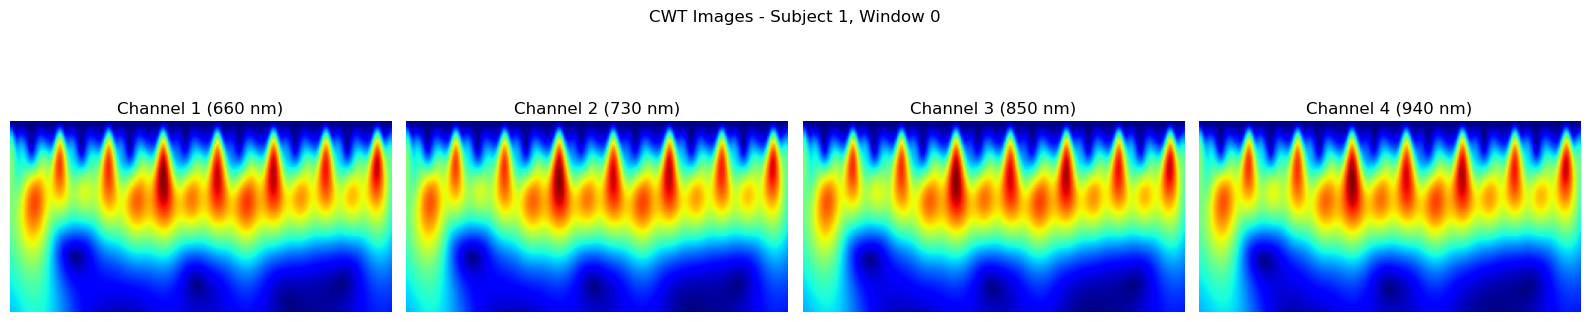

In [36]:
# Visualize one sample: 4 wavelength CWT images
sample_idx = 0
sample_cwt_hwc = np.transpose(X_train_cwt[sample_idx], (1, 2, 0))  # (12, H, W) → (H, W, 12)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
wavelengths = ["660 nm", "730 nm", "850 nm", "940 nm"]
for i in range(4):
    rgb_img = sample_cwt_hwc[:, :, i * 3 : (i + 1) * 3]
    axes[i].imshow(rgb_img)
    axes[i].set_title(f"Channel {i+1} ({wavelengths[i]})")
    axes[i].axis("off")
plt.suptitle(f"CWT Images - Subject {train_subjects[0]['id']}, Window 0")
plt.tight_layout()
plt.show()

## Phase 4: ACNN-BiLSTM Model (Paper Section 3.3, Figure 3)

Architecture from paper (following Figure 3 diagram):
- **Initial Conv2D** → ReLU → BN
- **7 ACNN blocks** (each: Conv2D → ReLU → BN → Channel Attention), stride=2 on blocks 1,3,5,6,7
- **2 BiLSTM layers** (lstm_hidden=256, compression ratio 1024:256 = 4:1)
- **FCN → Dropout → FCN → Dropout → BP output**

Stride pattern and lstm_hidden are not specified in the paper; chosen to give a workable
CNN→BiLSTM compression ratio (4:1 vs the previous 32:1 which prevented learning).


In [37]:
# ========================= Channel Attention (SE Block) =========================

class SEBlock(nn.Module):
    """Squeeze-and-Excitation channel attention mechanism."""
    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(channels // reduction, 4)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Linear(channels, hidden)
        self.fc2 = nn.Linear(hidden, channels)

    def forward(self, x):
        b, c, _, _ = x.shape
        y = self.pool(x).view(b, c)
        y = F.relu(self.fc1(y))
        y = torch.sigmoid(self.fc2(y)).view(b, c, 1, 1)
        return x * y


# ========================= ACNN Block (per paper Figure 3: Conv2D+ReLU+BN) =========================

class ACNNUnit(nn.Module):
    """Single ACNN block: Conv2D → ReLU → BN → Channel Attention (per Figure 3)."""
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1)
        self.act = nn.ReLU(inplace=True)
        self.bn = nn.BatchNorm2d(out_ch)
        self.attn = SEBlock(out_ch)

    def forward(self, x):
        x = self.conv(x)
        x = self.act(x)
        x = self.bn(x)
        x = self.attn(x)
        return x


# ========================= ACNN-BiLSTM Model =========================

class ACNNBiLSTM(nn.Module):
    def __init__(self, in_channels=12, lstm_hidden=256, dropout=0.2):
        super().__init__()

        # Initial Conv2D (paper Figure 3: standalone Conv2D before x7 ACNN block)
        self.init_conv = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.init_act = nn.ReLU(inplace=True)
        self.init_bn = nn.BatchNorm2d(32)

        # 7 ACNN blocks (paper Figure 3)
        # Stride=2 on blocks 1, 3, 5, 6, 7 for sufficient spatial reduction.
        # This ensures the BiLSTM input feat_dim is manageable (1024 vs 4096).
        # Paper does not specify the stride pattern.
        # Channel progression: 32 → 32 → 64 → 64 → 128 → 128 → 256
        self.block1 = ACNNUnit(32, 32, stride=2)    # H/2, W/2
        self.block2 = ACNNUnit(32, 32, stride=1)
        self.block3 = ACNNUnit(32, 64, stride=2)    # H/4, W/4
        self.block4 = ACNNUnit(64, 64, stride=1)
        self.block5 = ACNNUnit(64, 128, stride=2)   # H/8, W/8
        self.block6 = ACNNUnit(128, 128, stride=2)  # H/16, W/16
        self.block7 = ACNNUnit(128, 256, stride=2)  # H/32, W/32

        # For 128×256 input: after 5 stride-2 → (256, 4, 8)
        # BiLSTM: width (8) → seq_len, channels*height (256*4=1024) → features
        # Compression ratio: 1024 / 256 = 4:1 (workable for LSTM)
        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, TARGET_IMG_SIZE[0], TARGET_IMG_SIZE[1])
            feat = self._forward_cnn(dummy)
            _, c, h, w = feat.shape
            self.seq_len = w
            self.seq_feat = c * h
            print(f"CNN output shape: {feat.shape} → BiLSTM input: seq_len={w}, feat_dim={c*h}")
            print(f"  Compression ratio: {c*h}/{lstm_hidden} = {(c*h)/lstm_hidden:.1f}:1")

        # 2 BiLSTM layers (paper Figure 3)
        self.bilstm1 = nn.LSTM(self.seq_feat, lstm_hidden, batch_first=True, bidirectional=True)
        self.bilstm2 = nn.LSTM(lstm_hidden * 2, lstm_hidden, batch_first=True, bidirectional=True)

        # FC head (paper Figure 3: FCN → Dropout → FCN → Dropout → BP)
        self.fc1 = nn.Linear(lstm_hidden * 2, 128)
        self.drop1 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(128, 2)
        self.drop2 = nn.Dropout(dropout)

    def _forward_cnn(self, x):
        x = self.init_bn(self.init_act(self.init_conv(x)))
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        x = self.block6(x)
        x = self.block7(x)
        return x

    def forward(self, x):
        x = self._forward_cnn(x)               # (B, 256, 4, 8)

        b, c, h, w = x.shape
        # Reshape: width → sequence steps, channels*height → features
        x = x.permute(0, 3, 1, 2).contiguous()  # (B, W, C, H)
        x = x.view(b, w, c * h)                 # (B, 8, 1024)

        x, _ = self.bilstm1(x)
        x, _ = self.bilstm2(x)

        x = x[:, -1, :]                         # last timestep

        x = self.drop1(F.relu(self.fc1(x)))
        x = self.drop2(self.fc2(x))
        return x


print("Model classes defined (ReLU+BN, 5 stride-2 blocks, lstm_hidden=256).")


Model classes defined (ReLU+BN, 5 stride-2 blocks, lstm_hidden=256).


### 4.1 Verify Model with Dummy Input

In [38]:
# Verify model output shape with dummy input
if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

test_model = ACNNBiLSTM(in_channels=12, lstm_hidden=256, dropout=0.2)
dummy_input = torch.randn(2, 12, TARGET_IMG_SIZE[0], TARGET_IMG_SIZE[1])
with torch.no_grad():
    dummy_output = test_model(dummy_input)
print(f"Input shape:  {dummy_input.shape}")
print(f"Output shape: {dummy_output.shape}")  # Expected: (2, 2)
assert dummy_output.shape == (2, 2), f"Expected (2, 2), got {dummy_output.shape}"
print("Model verification passed!")

# Count parameters
total_params = sum(p.numel() for p in test_model.parameters())
trainable_params = sum(p.numel() for p in test_model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
del test_model


Using device: mps
CNN output shape: torch.Size([1, 256, 4, 8]) → BiLSTM input: seq_len=8, feat_dim=1024
  Compression ratio: 1024/256 = 4.0:1
Input shape:  torch.Size([2, 12, 128, 256])
Output shape: torch.Size([2, 2])
Model verification passed!
Total parameters: 4,878,482
Trainable parameters: 4,878,482


## Phase 5: Training with 10-Fold Cross-Validation (Paper Section 3.3)

Paper: *"the data in the ratio of 0.8 was used for training and 10-fold cross validation"*

In [39]:
# ========================= Dataset =========================

class BPDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# ========================= Training & Evaluation Helpers =========================

BATCH_SIZE = 32
NUM_EPOCHS = 500
PATIENCE = 150
LR = 1e-3  # Paper Section 3.3: "learning rate set to 0.001"


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)
    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    preds, targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            running_loss += criterion(outputs, y_batch).item() * X_batch.size(0)
            preds.append(outputs.cpu().numpy())
            targets.append(y_batch.cpu().numpy())
    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss, np.concatenate(preds), np.concatenate(targets)


def train_model(model, train_loader, val_loader, device, num_epochs=NUM_EPOCHS, patience=PATIENCE):
    """Train with early stopping. Fixed LR=0.001 per paper Section 3.3."""
    criterion = nn.L1Loss()  # MAE (paper Section 3.3)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    # No LR scheduler — paper specifies fixed lr=0.001
    best_val_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    patience_counter = 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(num_epochs):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, _, _ = evaluate(model, val_loader, criterion, device)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if (epoch + 1) % 10 == 0 or patience_counter >= patience:
            print(f"  Epoch {epoch+1}/{num_epochs} | Train MAE: {train_loss:.4f} | Val MAE: {val_loss:.4f}")

        if patience_counter >= patience:
            print(f"  Early stopping at epoch {epoch+1}")
            break

    model.load_state_dict(best_state)
    return model, history, best_val_loss


print("Training helpers defined (fixed LR=0.001, no scheduler, per paper).")
print(f"  NUM_EPOCHS={NUM_EPOCHS}, PATIENCE={PATIENCE}, BATCH_SIZE={BATCH_SIZE}, LR={LR}")


Training helpers defined (fixed LR=0.001, no scheduler, per paper).
  NUM_EPOCHS=500, PATIENCE=150, BATCH_SIZE=32, LR=0.001


### 5.1 Run 10-Fold Cross-Validation on Training Set

In [40]:
# ========================= 10-Fold CV SKIPPED (for faster experimentation) =========================
# Uncomment the block below once underfitting is resolved and you want stability metrics.

# Build subject-to-window mapping (needed by Phase 5.2 regardless of CV)
train_subject_ids = np.array([item["id"] for item in train_subjects])
subject_window_counts = np.array([item["X"].shape[0] for item in train_subjects])

cum_counts = np.cumsum(subject_window_counts)
start_indices = np.concatenate([[0], cum_counts[:-1]])

subject_to_window_idx = {}
for i, sid in enumerate(train_subject_ids):
    subject_to_window_idx[sid] = np.arange(start_indices[i], cum_counts[i])

print(f"Total training subjects: {len(train_subject_ids)}")
print(f"Total training windows: {cum_counts[-1]}")

# Full training dataset (CWT images already computed)
train_dataset_full = BPDataset(X_train_cwt, y_train_all)

print("10-Fold CV skipped. Proceeding directly to final training.")

# # Subject-level KFold
# kf = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
#
# cv_results = {
#     "fold": [], "val_mae_sbp": [], "val_mae_dbp": [],
#     "val_rmse_sbp": [], "val_rmse_dbp": [],
#     "val_r2_sbp": [], "val_r2_dbp": [],
# }
#
# for fold_idx, (train_subj_idx, val_subj_idx) in enumerate(kf.split(train_subject_ids)):
#     fold_train_sids = train_subject_ids[train_subj_idx]
#     fold_val_sids = train_subject_ids[val_subj_idx]
#
#     fold_train_win_idx = np.concatenate([subject_to_window_idx[sid] for sid in fold_train_sids])
#     fold_val_win_idx = np.concatenate([subject_to_window_idx[sid] for sid in fold_val_sids])
#
#     print(f"\n{'='*60}")
#     print(f"Fold {fold_idx + 1}/10 | Train subjects: {len(fold_train_sids)} | Val subjects: {len(fold_val_sids)}")
#     print(f"  Train windows: {len(fold_train_win_idx)} | Val windows: {len(fold_val_win_idx)}")
#     print(f"{'='*60}")
#
#     train_subset = Subset(train_dataset_full, fold_train_win_idx.tolist())
#     val_subset = Subset(train_dataset_full, fold_val_win_idx.tolist())
#
#     fold_train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
#     fold_val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
#
#     fold_model = ACNNBiLSTM(in_channels=12, lstm_hidden=128, dropout=0.2).to(device)
#
#     fold_model, history, best_val = train_model(
#         fold_model, fold_train_loader, fold_val_loader, device
#     )
#
#     criterion = nn.L1Loss()
#     _, val_preds, val_targets = evaluate(fold_model, fold_val_loader, criterion, device)
#
#     sbp_pred, dbp_pred = val_preds[:, 0], val_preds[:, 1]
#     sbp_true, dbp_true = val_targets[:, 0], val_targets[:, 1]
#
#     cv_results["fold"].append(fold_idx + 1)
#     cv_results["val_mae_sbp"].append(mean_absolute_error(sbp_true, sbp_pred))
#     cv_results["val_mae_dbp"].append(mean_absolute_error(dbp_true, dbp_pred))
#     cv_results["val_rmse_sbp"].append(np.sqrt(mean_squared_error(sbp_true, sbp_pred)))
#     cv_results["val_rmse_dbp"].append(np.sqrt(mean_squared_error(dbp_true, dbp_pred)))
#     cv_results["val_r2_sbp"].append(r2_score(sbp_true, sbp_pred))
#     cv_results["val_r2_dbp"].append(r2_score(dbp_true, dbp_pred))
#
#     print(f"  Fold {fold_idx+1} Results:")
#     print(f"    SBP → MAE: {cv_results['val_mae_sbp'][-1]:.2f}, RMSE: {cv_results['val_rmse_sbp'][-1]:.2f}, R²: {cv_results['val_r2_sbp'][-1]:.4f}")
#     print(f"    DBP → MAE: {cv_results['val_mae_dbp'][-1]:.2f}, RMSE: {cv_results['val_rmse_dbp'][-1]:.2f}, R²: {cv_results['val_r2_dbp'][-1]:.4f}")
#
#     del fold_model
#     if device.type == "cuda":
#         torch.cuda.empty_cache()
#     elif device.type == "mps":
#         torch.mps.empty_cache()
#
# # ========================= CV Summary =========================
# print(f"\n{'='*60}")
# print("10-Fold SUBJECT-LEVEL Cross-Validation Summary (mean ± std)")
# print(f"{'='*60}")
# for metric in ["val_mae", "val_rmse", "val_r2"]:
#     for bp in ["sbp", "dbp"]:
#         key = f"{metric}_{bp}"
#         vals = np.array(cv_results[key])
#         print(f"  {bp.upper()} {metric.split('_')[1].upper()}: {vals.mean():.4f} ± {vals.std():.4f}")


Total training subjects: 144
Total training windows: 7997
10-Fold CV skipped. Proceeding directly to final training.


### 5.2 Final Training on Full Training Set & Test Evaluation

Final training: 129 subjects (7167 windows)
Final validation (for early stopping): 15 subjects (830 windows)

Training final model...
CNN output shape: torch.Size([1, 256, 4, 8]) → BiLSTM input: seq_len=8, feat_dim=1024
  Compression ratio: 1024/256 = 4.0:1
  Epoch 10/500 | Train MAE: 31.8751 | Val MAE: 12.9710
  Epoch 20/500 | Train MAE: 29.0661 | Val MAE: 14.6020
  Epoch 30/500 | Train MAE: 27.8607 | Val MAE: 18.1031
  Epoch 40/500 | Train MAE: 26.6291 | Val MAE: 18.3487
  Epoch 50/500 | Train MAE: 25.6303 | Val MAE: 16.9378
  Epoch 60/500 | Train MAE: 25.8869 | Val MAE: 16.5042
  Epoch 70/500 | Train MAE: 24.5882 | Val MAE: 16.3187
  Epoch 80/500 | Train MAE: 25.0325 | Val MAE: 17.4336
  Epoch 90/500 | Train MAE: 24.6399 | Val MAE: 16.4660
  Epoch 100/500 | Train MAE: 24.2029 | Val MAE: 15.8280
  Epoch 110/500 | Train MAE: 23.9649 | Val MAE: 17.6246
  Epoch 120/500 | Train MAE: 24.2773 | Val MAE: 17.3919
  Epoch 130/500 | Train MAE: 24.2353 | Val MAE: 16.7001
  Epoch 140/500 | Train

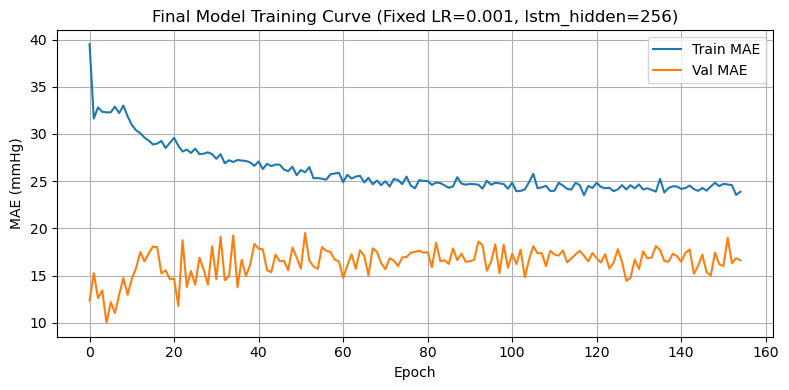

In [41]:
# Retrain on full training set, then evaluate on held-out 20% test set
# Use subject-level split for the early-stopping validation set

test_dataset = BPDataset(X_test_cwt, y_test_all)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Subject-level 90/10 split of training subjects for early stopping
np.random.seed(RANDOM_STATE)
n_subj = len(train_subject_ids)
shuffled_subj_idx = np.random.permutation(n_subj)
subj_split = int(0.9 * n_subj)

final_train_sids = train_subject_ids[shuffled_subj_idx[:subj_split]]
final_val_sids = train_subject_ids[shuffled_subj_idx[subj_split:]]

final_train_win_idx = np.concatenate([subject_to_window_idx[sid] for sid in final_train_sids])
final_val_win_idx = np.concatenate([subject_to_window_idx[sid] for sid in final_val_sids])

print(f"Final training: {len(final_train_sids)} subjects ({len(final_train_win_idx)} windows)")
print(f"Final validation (for early stopping): {len(final_val_sids)} subjects ({len(final_val_win_idx)} windows)")

final_train_loader = DataLoader(Subset(train_dataset_full, final_train_win_idx.tolist()), batch_size=BATCH_SIZE, shuffle=True)
final_val_loader = DataLoader(Subset(train_dataset_full, final_val_win_idx.tolist()), batch_size=BATCH_SIZE, shuffle=False)

print("\nTraining final model...")
final_model = ACNNBiLSTM(in_channels=12, lstm_hidden=256, dropout=0.2).to(device)

final_model, final_history, final_best_val = train_model(
    final_model, final_train_loader, final_val_loader, device
)

print(f"\nBest validation MAE: {final_best_val:.4f}")

# Plot training curves
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(final_history["train_loss"], label="Train MAE")
ax.plot(final_history["val_loss"], label="Val MAE")
ax.set_xlabel("Epoch")
ax.set_ylabel("MAE (mmHg)")
ax.set_title("Final Model Training Curve (Fixed LR=0.001, lstm_hidden=256)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


## Phase 6: Evaluation Metrics (Paper Section 3.4, Tables 1-4)

Metrics: R², ME ± SD, MAE, RMSE, AAMI criteria, BHS grades, Bland-Altman plots

In [42]:
# ========================= Metric Functions =========================

def compute_all_metrics(y_true, y_pred, name=""):
    """Compute R², ME ± SD, MAE, RMSE, AAMI check, BHS grade (paper Section 3.4)."""
    errors = y_pred - y_true

    r2 = r2_score(y_true, y_pred)
    me = np.mean(errors)
    sd = np.std(errors)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # AAMI criteria: ME < ±5 mmHg, SD < 8 mmHg
    aami_pass = (abs(me) < 5) and (sd < 8)

    # BHS grade: % of absolute errors ≤5, ≤10, ≤15 mmHg
    abs_errors = np.abs(errors)
    pct_5 = np.mean(abs_errors <= 5) * 100
    pct_10 = np.mean(abs_errors <= 10) * 100
    pct_15 = np.mean(abs_errors <= 15) * 100

    if pct_5 >= 60 and pct_10 >= 85 and pct_15 >= 95:
        bhs_grade = "A"
    elif pct_5 >= 50 and pct_10 >= 75 and pct_15 >= 90:
        bhs_grade = "B"
    elif pct_5 >= 40 and pct_10 >= 65 and pct_15 >= 85:
        bhs_grade = "C"
    else:
        bhs_grade = "D"

    print(f"\n{'='*50}")
    print(f"  {name} Results")
    print(f"{'='*50}")
    print(f"  R²:        {r2:.4f}")
    print(f"  ME ± SD:   {me:.2f} ± {sd:.2f} mmHg")
    print(f"  MAE:       {mae:.2f} mmHg")
    print(f"  RMSE:      {rmse:.2f} mmHg")
    print(f"  AAMI:      {'Yes' if aami_pass else 'No'} (ME<±5: {abs(me)<5}, SD<8: {sd<8})")
    print(f"  BHS Grade: {bhs_grade} (≤5: {pct_5:.1f}%, ≤10: {pct_10:.1f}%, ≤15: {pct_15:.1f}%)")

    return {
        "r2": r2, "me": me, "sd": sd, "mae": mae, "rmse": rmse,
        "aami": aami_pass, "bhs_grade": bhs_grade,
        "pct_5": pct_5, "pct_10": pct_10, "pct_15": pct_15,
    }


def bland_altman_plot(y_true, y_pred, title="Bland-Altman"):
    """Bland-Altman plot (paper Figure 4)."""
    mean_vals = (y_true + y_pred) / 2
    diff_vals = y_pred - y_true
    mean_diff = np.mean(diff_vals)
    sd_diff = np.std(diff_vals)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(mean_vals, diff_vals, alpha=0.4, s=10, c="steelblue")
    ax.axhline(mean_diff, color="red", linestyle="--", label=f"Mean: {mean_diff:.3f}")
    ax.axhline(mean_diff + 1.96 * sd_diff, color="gray", linestyle="--",
               label=f"+1.96 SD: {mean_diff + 1.96*sd_diff:.3f}")
    ax.axhline(mean_diff - 1.96 * sd_diff, color="gray", linestyle="--",
               label=f"-1.96 SD: {mean_diff - 1.96*sd_diff:.3f}")
    ax.set_xlabel("Mean (mmHg)")
    ax.set_ylabel("Difference (mmHg)")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


print("Evaluation functions defined.")

Evaluation functions defined.


### 6.1 Test Set Evaluation

In [43]:
# ========================= Evaluate on Test Set =========================

criterion = nn.L1Loss()
test_loss, test_preds, test_targets = evaluate(final_model, test_loader, criterion, device)

print(f"Test MAE (overall): {test_loss:.4f}")

# SBP metrics
sbp_metrics = compute_all_metrics(test_targets[:, 0], test_preds[:, 0], name="SBP (Systolic)")

# DBP metrics
dbp_metrics = compute_all_metrics(test_targets[:, 1], test_preds[:, 1], name="DBP (Diastolic)")

# ========================= Summary Table (like paper Table 2) =========================
print(f"\n{'='*80}")
print(f"{'Trial 3 (MWPPG Fusion)':^80}")
print(f"{'='*80}")
print(f"{'':15} {'R²':>6} {'ME ± SD':>15} {'MAE':>8} {'RMSE':>8} {'AAMI':>6} {'BHS':>5}")
print(f"{'SBP (mmHg)':15} {sbp_metrics['r2']:>6.2f} {sbp_metrics['me']:>6.2f} ± {sbp_metrics['sd']:<6.2f} {sbp_metrics['mae']:>8.2f} {sbp_metrics['rmse']:>8.2f} {'Yes' if sbp_metrics['aami'] else 'No':>6} {sbp_metrics['bhs_grade']:>5}")
print(f"{'DBP (mmHg)':15} {dbp_metrics['r2']:>6.2f} {dbp_metrics['me']:>6.2f} ± {dbp_metrics['sd']:<6.2f} {dbp_metrics['mae']:>8.2f} {dbp_metrics['rmse']:>8.2f} {'Yes' if dbp_metrics['aami'] else 'No':>6} {dbp_metrics['bhs_grade']:>5}")

Test MAE (overall): 17.9983

  SBP (Systolic) Results
  R²:        -0.7603
  ME ± SD:   -21.96 ± 25.18 mmHg
  MAE:       23.37 mmHg
  RMSE:      33.41 mmHg
  AAMI:      No (ME<±5: False, SD<8: False)
  BHS Grade: D (≤5: 22.1%, ≤10: 47.0%, ≤15: 49.8%)

  DBP (Diastolic) Results
  R²:        -0.5341
  ME ± SD:   -10.31 ± 14.11 mmHg
  MAE:       12.63 mmHg
  RMSE:      17.47 mmHg
  AAMI:      No (ME<±5: False, SD<8: False)
  BHS Grade: D (≤5: 27.7%, ≤10: 61.0%, ≤15: 72.3%)

                             Trial 3 (MWPPG Fusion)                             
                    R²         ME ± SD      MAE     RMSE   AAMI   BHS
SBP (mmHg)       -0.76 -21.96 ± 25.18     23.37    33.41     No     D
DBP (mmHg)       -0.53 -10.31 ± 14.11     12.63    17.47     No     D


### 6.2 Bland-Altman Plots (Paper Figure 4)

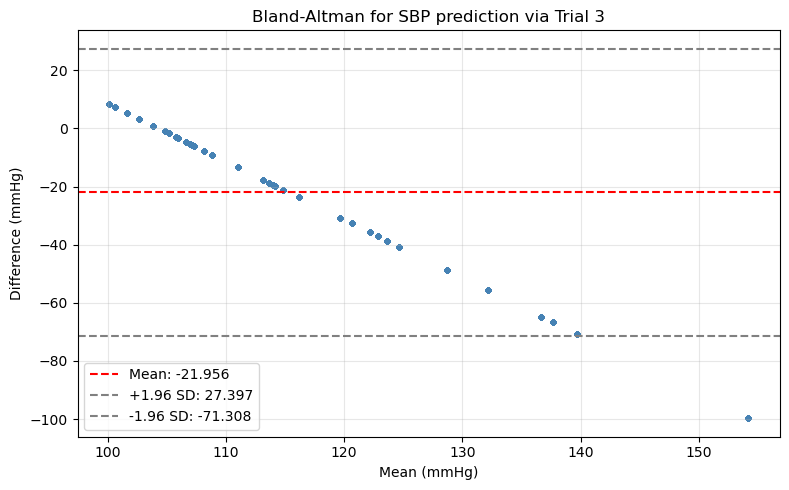

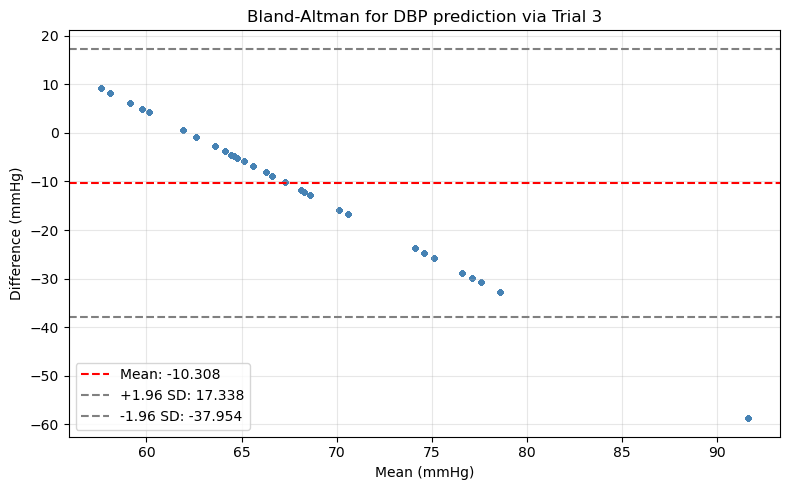

In [44]:
bland_altman_plot(test_targets[:, 0], test_preds[:, 0],
                 title="Bland-Altman for SBP prediction via Trial 3")

bland_altman_plot(test_targets[:, 1], test_preds[:, 1],
                 title="Bland-Altman for DBP prediction via Trial 3")

### 6.3 BHS Grade Tables (Paper Tables 3 & 4)

In [45]:
# BHS Grade Table
print("BHS Scheme - SBP Prediction")
print(f"{'':15} {'≤5 mmHg':>10} {'≤10 mmHg':>10} {'≤15 mmHg':>10}")
print(f"{'Trial 3':15} {sbp_metrics['pct_5']:>9.0f}% {sbp_metrics['pct_10']:>9.0f}% {sbp_metrics['pct_15']:>9.0f}%")
print(f"{'Grade A':15} {'60%':>10} {'85%':>10} {'95%':>10}")
print(f"{'Grade B':15} {'50%':>10} {'75%':>10} {'90%':>10}")
print(f"{'Grade C':15} {'40%':>10} {'65%':>10} {'85%':>10}")

print(f"\nBHS Scheme - DBP Prediction")
print(f"{'':15} {'≤5 mmHg':>10} {'≤10 mmHg':>10} {'≤15 mmHg':>10}")
print(f"{'Trial 3':15} {dbp_metrics['pct_5']:>9.0f}% {dbp_metrics['pct_10']:>9.0f}% {dbp_metrics['pct_15']:>9.0f}%")
print(f"{'Grade A':15} {'60%':>10} {'85%':>10} {'95%':>10}")
print(f"{'Grade B':15} {'50%':>10} {'75%':>10} {'90%':>10}")
print(f"{'Grade C':15} {'40%':>10} {'65%':>10} {'85%':>10}")

BHS Scheme - SBP Prediction
                   ≤5 mmHg   ≤10 mmHg   ≤15 mmHg
Trial 3                22%        47%        50%
Grade A                60%        85%        95%
Grade B                50%        75%        90%
Grade C                40%        65%        85%

BHS Scheme - DBP Prediction
                   ≤5 mmHg   ≤10 mmHg   ≤15 mmHg
Trial 3                28%        61%        72%
Grade A                60%        85%        95%
Grade B                50%        75%        90%
Grade C                40%        65%        85%


### 6.4 Save Model

In [46]:
save_path = Path("/Users/ahmadrasool/Downloads/Bioengineering_Paper_project_data/modelschedular.pth")
torch.save(final_model.state_dict(), save_path)
print(f"Model saved to {save_path}")

Model saved to /Users/ahmadrasool/Downloads/Bioengineering_Paper_project_data/modelschedular.pth
